In [1]:
from mlx.nn import ReLU
import mlx.data as dx
import mlx.core as mx

from src.config import OptimizerConfig, EncoderConfig
from src.processing import get_all_dataset, get_trades_tokenizer, get_volatility_seq, save_tokenizer, load_tokenizer, get_num_embedding, compute_df_feature, encode_df_feature

CATEGORIAL_COLUMNS = ["TradeType", "MifidInstrumentID", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"]
CONTINUOUS_COLUMNS = ["delta_event_ts", "log_volume", "norm_volume", "time_cos", "time_sin"]
SEQUENCE_SIZE = 60
VOLATILITY_SCALE = 1.
SAVE_DIR = "weight"
ENCODER_DEPTH = 4
EMBEDDING_DIM = [4, 8, 4, 4, 4, 4] # 8 for InstrumentID to get better clustering

dataset = get_all_dataset(dir="equities_trade")

print(f"👾 Load {len(dataset)} trades")
print(dataset.tail(1))

tokenizer = load_tokenizer(path="tokenizer.json") 

dataset = encode_df_feature(dataset, tokenizer)
dataset = compute_df_feature(dataset, norm_log_return_window=10, norm_volume_window=10)


encoder_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM,
                              num_embedding=get_num_embedding(dataset, CATEGORIAL_COLUMNS),
                              categorical_col=CATEGORIAL_COLUMNS)

dataset


Found 6 files in directory
👾 Load 6427974 trades
shape: (1, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ EventTime  ┆ TradingDat ┆ Publicatio ┆ MifidInst ┆ … ┆ MmtMarket ┆ MmtTradin ┆ MmtAlgori ┆ Venue │
│ ---        ┆ eTime      ┆ nDateTime  ┆ rumentID  ┆   ┆ Mechanism ┆ gMode     ┆ thmicIndi ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ cator     ┆ str   │
│            ┆ str        ┆ str        ┆ str       ┆   ┆ str       ┆ str       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆           ┆           ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ 2026-03-12 ┆ 2026-03-12 ┆ 2026-03-12 ┆ FR001400A ┆ … ┆ 4         ┆ 5         ┆ human     ┆ XPAR  │
│ T16:55:52. ┆ T16:55:23. ┆ T16:55:53. ┆ HX6       ┆   ┆           ┆           ┆           ┆       │
│ 000000000Z ┆ 000000Z    ┆

MifidInstrumentID,delta_event_ts,delta_trading_ts,delta_publication_ts,log_return,log_volume,norm_log_return,norm_volume,TradeType,MmtMarketMechanism,MmtTradingMode,MmtAlgorithmicIndicator,Venue,event_ts,time_cos,time_sin
i32,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[i32],list[i32],list[i32],list[i32],list[i64],list[f64],list[f64]
530,"[17.921431, 0.0, … 23.11202]","[17.921431, 0.0, … 23.11202]","[17.921432, 0.0, … 23.11202]","[-0.005571, 0.0, … 0.008253]","[2.079442, 4.234107, … 0.693147]","[-0.003909, 0.001111, … 0.008253]","[-1.099037, 0.85194, … -0.738833]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 1]","[1, 1, … 0]","[2, 2, … 2]","[1774019454640317, 1774019454640317, … 1773330144603362]","[0.819726, 0.819726, … -0.713587]","[-0.572756, -0.572756, … 0.700567]"
170,"[0.0, 0.0, … 16.723248]","[0.0, 0.0, … 16.723248]","[0.0, 0.693147, … 16.723124]","[0.0, 0.0, … 0.0]","[1.94591, 2.079442, … 2.772589]","[0.0, 0.0, … 0.0]","[-0.233964, -0.129201, … -2.054171]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 3]","[1, 1, … 1]","[1, 1, … 1]","[1773907213074558, 1773907213074558, … 1773333324831371]","[0.090014, 0.090014, … -0.992984]","[0.99594, 0.99594, … 0.118245]"
15,"[19.912846, 18.79567, … 0.0]","[19.912846, 18.79567, … 0.0]","[19.912846, 18.79567, … 0.0]","[0.012739, -0.014572, … 0.0]","[7.601402, 8.517393, … 0.693147]","[0.011282, -0.014572, … 0.0]","[1.27592, 1.801684, … -5.090947]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 0]","[1, 1, … 1]","[1773910860029954, 1773911005527464, … 1773333319555918]","[-0.609064, -0.632484, … -0.992392]","[0.793121, 0.774574, … 0.123115]"
402,"[22.97863, 25.06537, … 25.182047]","[22.97863, 25.06537, … 25.182047]","[22.97863, 25.06537, … 25.182047]","[0.010471, 0.0, … 0.0]","[3.044522, 0.693147, … 0.693147]","[0.010471, 0.0, … 0.0]","[1.304974, -1.046402, … -0.235138]","[4, 4, … 4]","[0, 0, … 0]","[1, 4, … 4]","[0, 1, … 1]","[1, 1, … 1]","[1773052759036277, 1773129628157795, … 1773302409820805]","[-0.378177, 0.447188, … -0.982577]","[0.925733, -0.89444, … 0.185858]"
277,"[20.542727, 0.0, … 21.166358]","[20.542727, 0.0, … 21.166358]","[20.542727, 0.0, … 21.166358]","[-0.007101, -0.002378, … 0.0]","[4.890349, 0.693147, … 2.564949]","[-0.006155, -0.001195, … -0.00095]","[2.385668, -1.742219, … -0.57504]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 1]","[1, 1, … 1]","[1773918492338013, 1773918492338013, … 1773333303255886]","[-0.795189, -0.795189, … -0.992004]","[-0.606361, -0.606361, … 0.126209]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
360,"[0.0, 0.0, … 23.614681]","[0.0, 0.0, … 23.614681]","[0.0, 0.0, … 23.614681]","[0.0, 0.0, … 0.019608]","[2.772589, 2.397895, … 0.693147]","[0.0, 0.0, … 0.016653]","[1.180972, 0.67635, … -0.138629]","[4, 4, … 4]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 1]","[1, 1, … 1]","[1773675007440180, 1773675007440180, … 1773415823365422]","[0.93226, 0.93226, … -0.84818]","[0.36179, 0.36179, … -0.529708]"
128,"[NaN, 23.177797, … 25.182467]","[NaN, 23.177797, … 25.182467]","[NaN, 23.177797, … 25.182467]","[-0.039221, 0.0, … 0.05557]","[0.693147, 2.995732, … 0.693147]","[-0.035299, 0.003922, … 0.055028]","[-0.869031, 1.203296, … -1.099289]","[4, 4, … 4]","[0, 0, … 0]","[4, 3, … 4]","[1, 0, … 0]","[1, 1, … 1]","[1773052223222703, 1773063864198502, … 1773225027177938]","[1.0, -0.73079, … -0.601986]","[0.0, 0.682602, … -0.798506]"
244,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.693147, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[5.934894, 3.044522, … 0.693147]","[0.001212, 0.001212, … 0.0]","[-0.034906, -2.608269, … -3.625795]","[4, 4, … 4]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 1]","[3, 3, … 3]","[1773675027700700, 1773675027700700, … 1773243013976905]","[-0.602527, -0.602527, … 0.095208]","[0.798098, 0.798098, … 0.995457]"


====== Volatility Model ===== (Task B)

In [2]:
from src.trainer import VolatilityTrainer
from src.volatility_nn import VolatilityPredictor
from src.config import VolatilityConfig

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=10, 
              save_dir=SAVE_DIR, 
              model_name="volatility_model", 
              plot_chart=True)



100%|██████████| 598/598 [01:11<00:00,  8.36it/s]


Target mean -->  0.90912896 +/- 2.4164057
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]
MLX Buffer size --> 6362775
MLX train buffer init in  29.38499689102173
MLX test buffer init in  19.03362202644348
EPOCH 1 --- 


4350it [1:05:16,  1.11it/s]
1865it [04:45,  6.54it/s]


TRAIN LOSS 2.1326349565791016 ||| TEST LOSS 1.4861629248048964
EPOCH 2 --- 


4350it [1:03:22,  1.14it/s]
1865it [05:40,  5.48it/s]


...

TRAIN LOSS 2.1327298425257806 ||| TEST LOSS 1.479953398205958
EPOCH 7 --- 


4350it [1:01:52,  1.17it/s]
1865it [05:03,  6.14it/s]


TRAIN LOSS 2.1337883730702 ||| TEST LOSS 1.481615029864275
EPOCH 8 --- 


3539it [51:43,  1.14it/s]


KeyboardInterrupt: 

100%|██████████| 598/598 [01:22<00:00,  7.21it/s]


Target mean -->  0.9091292 +/- 2.416408
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]


100%|██████████| 63628/63628 [01:52<00:00, 566.50it/s]


3 <_top k
View of topk -> shape: (3, 2)
┌─────────┬──────────┐
│ isin_id ┆ score    │
│ ---     ┆ ---      │
│ i64     ┆ f64      │
╞═════════╪══════════╡
│ 104     ┆ 0.885429 │
│ 116     ┆ 0.867289 │
│ 262     ┆ 0.81881  │
└─────────┴──────────┘


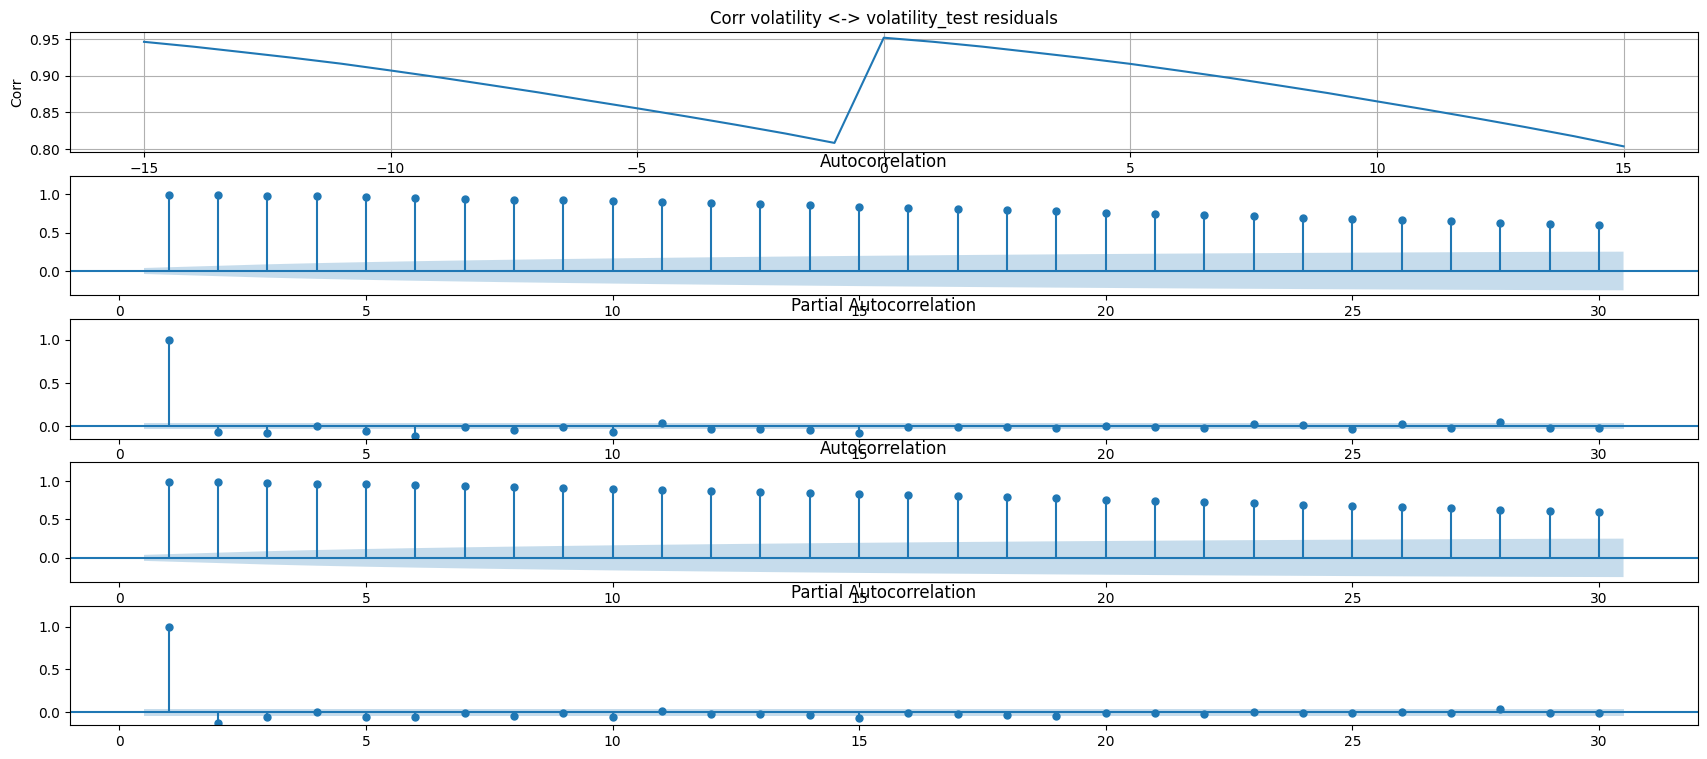

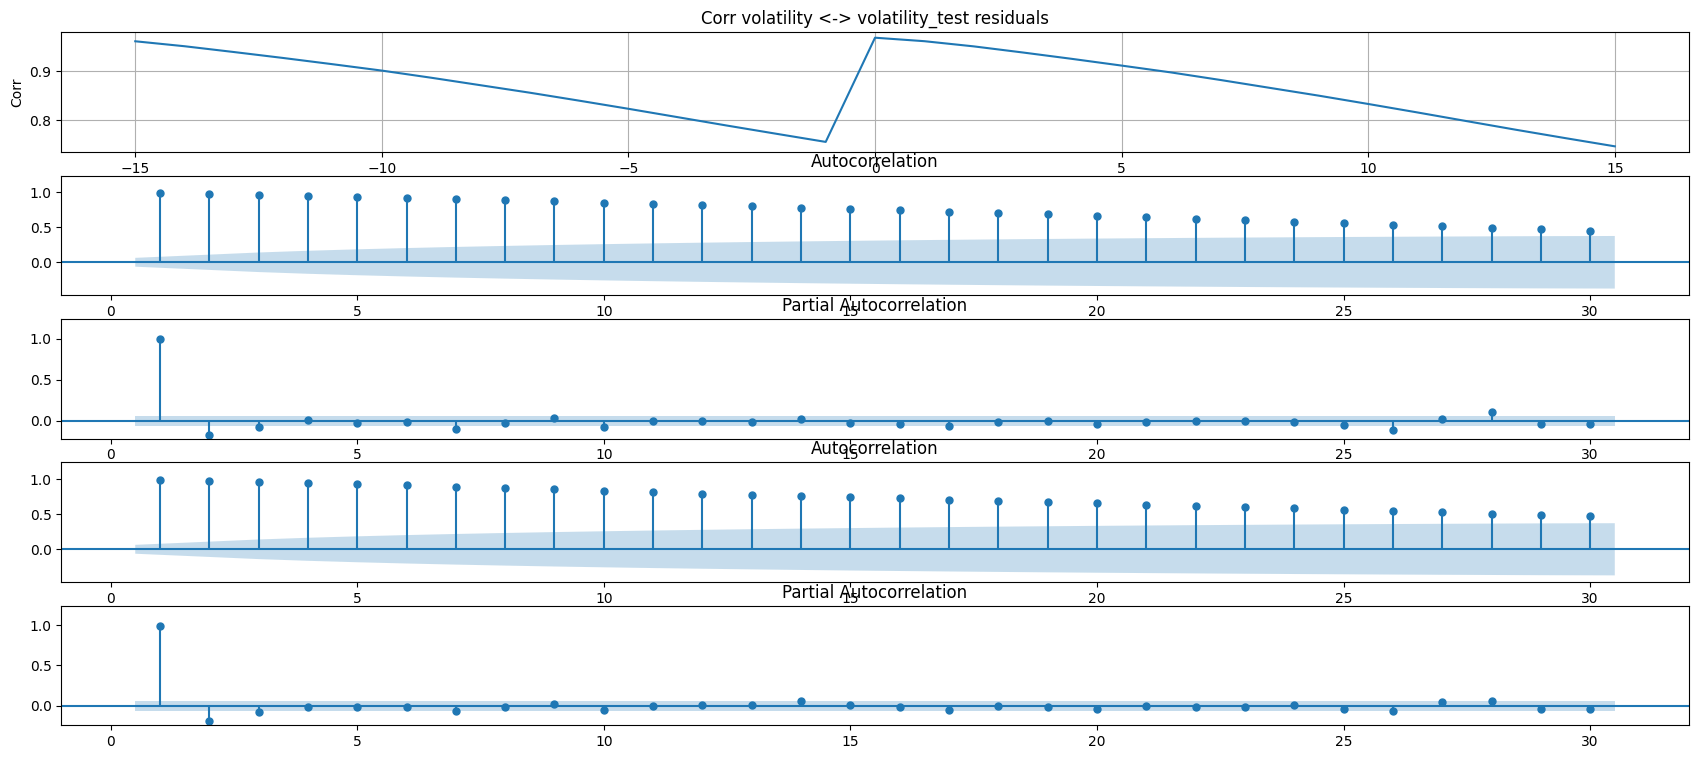

IndexError: index 30 is out of bounds for axis 0 with size 30

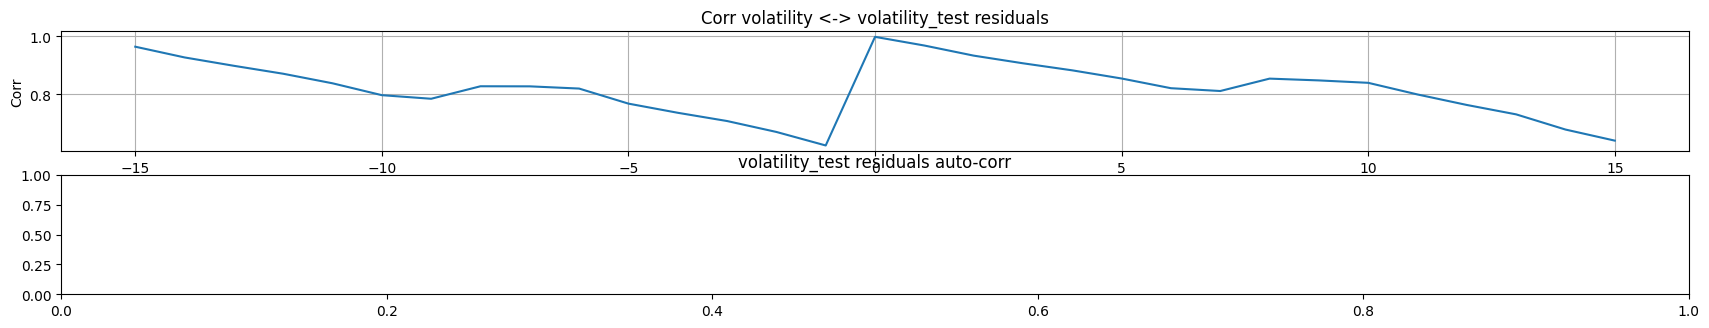

In [2]:
from src.analysis import analyse_volatility_residuals
from src.volatility_nn import VolatilityPredictor
from src.config import VolatilityConfig

TRAIN_SIZE=0.99

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)


volatility_model = VolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
volatility_model.load_weights("weight/volatility_model.safetensors")
mx.eval(volatility_model.parameters())

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)

train_lenght = int(len(buffer)*TRAIN_SIZE)
#buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])

#volatility_sequence_train = mx.array([[float(buffer_train[i]["target"]), int(buffer_train[i]["categorical"][0, 1])]for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([[float(buffer_test[i]["target"]), int(buffer_test[i]["categorical"][0, 1])] for i in range(len(buffer_test))], dtype=mx.float32)

analyse_volatility_residuals(model=volatility_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS, save_fig = True, name="volatility_test")
#analyse_volatility_residuals(model=volatility_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="volatility_train")


In [ ]:
import importlib
import src.analysis
importlib.reload(src.analysis)
from src.analysis import plot_hook_path, get_volatility_model_activation, get_hook_similiarity
import seaborn as sns
import pandas as pd

tree_activation = get_volatility_model_activation(model=volatility_model,
                                                  buffer=buffer_test,
                                                  categorical_col=CATEGORIAL_COLUMNS,
                                                  scale= VOLATILITY_SCALE,
                                                  max_isin=10) # We test only on ten asset 
                                                               # @todo find a way to reduce memory print & augment asset's number
                                                            

score, avg_score = get_hook_similiarity(tree=tree_activation, top_layer=0.3)
print("avg score->", avg_score)
print("score->", score)

score_df = pd.DataFrame(score, columns=list(tree_activation.keys()), index=list(tree_activation.keys()))
sns.heatmap(score_df, annot=True)



===========VAE MODEL===========

In [ ]:
#import importlib
#import src.vae
#importlib.reload(src.vae)
import time
from src.config import VAEConfig
from src.vae import VAE
from src.trainer import VAETrainer
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

optim_vae_config = OptimizerConfig(
    optimizer_name="adamw", 
    lr = 1e-4
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
mx.eval(vae_model.parameters())

vae_sequence = get_vae_seq(data=dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
start = time.time()
vae_buffer = dx.buffer_from_vector(vae_sequence)
print('MLX buffer init in ', time.time() - start, "second")
vae_trainer = VAETrainer(model=vae_model, 
                         optim_config=optim_vae_config, 
                         buffer=vae_buffer, 
                         categorical_columns=CATEGORIAL_COLUMNS,
                         train_size=0.7, 
                         batch_size=1024) 

vae_trainer.epoch(n_epoch=10,
                  save_dir= SAVE_DIR,
                  model_name="vae",
                  plot_chart=True)


100%|██████████| 598/598 [00:17<00:00, 34.91it/s]


MLX buffer init in  27.671177864074707 second
MLX train buffer init in  15.911517858505249
MLX test buffer init in  8.679965734481812
EPOCH 1 --- 


4350it [57:30,  1.26it/s]
1865it [03:31,  8.81it/s]


TRAIN LOSS -178.1211420199515 ||| TEST LOSS -144.0472063079916
EPOCH 2 --- 


4350it [59:00,  1.23it/s]
1865it [03:52,  8.02it/s]


...

TRAIN LOSS -180.66470094176543 ||| TEST LOSS -144.07314792663738
EPOCH 8 --- 


4350it [1:07:21,  1.08it/s]
1865it [05:29,  5.65it/s]


TRAIN LOSS -180.66842719417878 ||| TEST LOSS -144.07596220369314
EPOCH 9 --- 


3133it [47:27,  1.10it/s]


KeyboardInterrupt: 

In [2]:
from src.analysis import analyse_vae_residuals
from src.vae import VAE
from src.config import VAEConfig
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.safetensors")
mx.eval(vae_model.parameters())
TRAIN_SIZE=0.7

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
train_lenght = int(len(buffer)*TRAIN_SIZE)
buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])

volatility_sequence_train = mx.array([float(buffer_train[i]["target"]) for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([float(buffer_test[i]["target"]) for i in range(len(buffer_test))], dtype=mx.float32)

analyse_vae_residuals(model=vae_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_train")
analyse_vae_residuals(model=vae_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_test")


100%|██████████| 598/598 [01:22<00:00,  7.25it/s]


Target mean -->  0.90912926 +/- 2.4164069
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]


  0%|          | 3626/4453942 [00:10<3:25:46, 360.45it/s]


KeyboardInterrupt: 

==== Prediction Head without encoder pretrained ====

In [ ]:
import src.processing
import src.trainer
import importlib
importlib.reload(src.processing)
importlib.reload(src.trainer)
from src.config import DiscreteConfig
from src.volatility_predictor_nn import DiscreteHead
from src.trainer import DiscretizedVolTrainer
from src.processing import get_volatility_discretize_seq

directional_config = DiscreteConfig(
    num_states=3,
    hidden_size = 32,
    activation = ReLU,
    dropout_rate=0.2
)

directional_model = DiscreteHead(encoder_config=encoder_config, dir_config=directional_config)
mx.eval(directional_model.parameters())
directional_optim_config = OptimizerConfig(optimizer_name="adamw", lr=1e-4)

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )
directional_trainer.epoch(n_epoch=5, save_dir=SAVE_DIR, model_name="no_pretrain_discrete_model", plot_chart=True)


100%|██████████| 598/598 [02:31<00:00,  3.95it/s]


MLX train buffer init in  29.788903951644897
MLX test buffer init in  19.21560311317444
EPOCH 1 --- 


7it [00:09,  1.38s/it]


KeyboardInterrupt: 

: 

==== Prediction Head with VAE encoder ======

In [ ]:
VAE_WEIGHT = "weight/vae.safetensors"
directional_model_vae = DiscreteHead(encoder_config=encoder_config, 
                                    dir_config=directional_config,
                                    encoder_weight=VAE_WEIGHT)
directional_model_vae.encoder.freeze()

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )

directional_trainer.epoch(n_epoch=5, save_dir=SAVE_DIR, model_name="vae_pretrain_discrete_model", plot_chart=True)


(1000,)

In [ ]:
VOL_WEIGHT = "weight/volatility_model.safetensors"
directional_model_volatility = DiscreteHead(encoder_config=encoder_config, 
                                    dir_config=directional_config,
                                    encoder_weight=VOL_WEIGHT)
directional_model_volatility.encoder.freeze()

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )

directional_trainer.epoch(n_epoch=5, 
                          save_dir=SAVE_DIR, 
                          model_name="volatility_pretrain_discrete_model", 
                          plot_chart=True)
